# 1. Import necessary libraries

In [ ]:
import pandas as pd
import numpy as np
from typing import Dict
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, ConfusionMatrixDisplay
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt


# 2. Data preprocessing/exploration

<Axes: xlabel='label'>

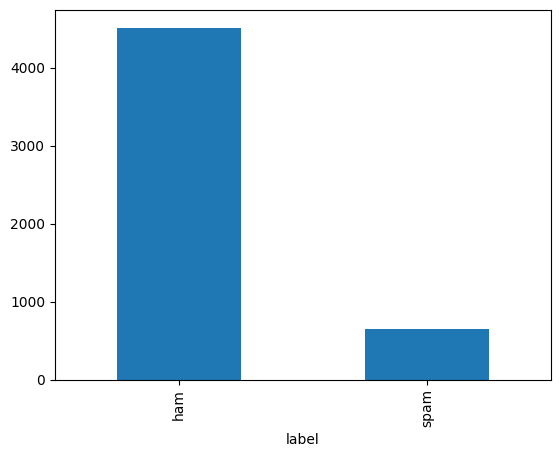

In [4]:
df: pd.DataFrame = pd.read_csv("spamhamdata.csv", sep="\t", names=["label", "message"])

df.drop_duplicates(inplace=True)
df.label.value_counts().plot.bar()

In [9]:
X: pd.Series = df['message']
y: pd.Series = df['label'].map({"spam": 1, "ham": 0})

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

pipeline = Pipeline([
    ('scaler', TfidfVectorizer()),
    ('classifier', LogisticRegression())
])

# 3. Training the model

In [6]:
pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None


# 4. Hypertuning parameters using GridSearchCV

In [10]:
param_grid: Dict[list, np.array] = {
    'classifier__max_iter': [100,1000,2500,5000],
    'classifier__C': np.logspace(-4,4,20)
}

grid_search: GridSearchCV = GridSearchCV(estimator=pipeline, param_grid=param_grid, cv=5, verbose=True)

grid_search.fit(X_train,y_train)

print("best accuracy", grid_search.best_score_)
print(grid_search.best_estimator_)
print(grid_search.best_params_)

Fitting 5 folds for each of 80 candidates, totalling 400 fits
best accuracy 0.9854897218863362
Pipeline(steps=[('scaler', TfidfVectorizer()),
                ('classifier',
                 LogisticRegression(C=np.float64(206.913808111479)))])
{'classifier__C': np.float64(206.913808111479), 'classifier__max_iter': 100}


# 5. Evaluation of model

Accuracy: 0.9825918762088974
Precision: 0.959349593495935
Recall: 0.9007633587786259
F1 score: 0.9291338582677166


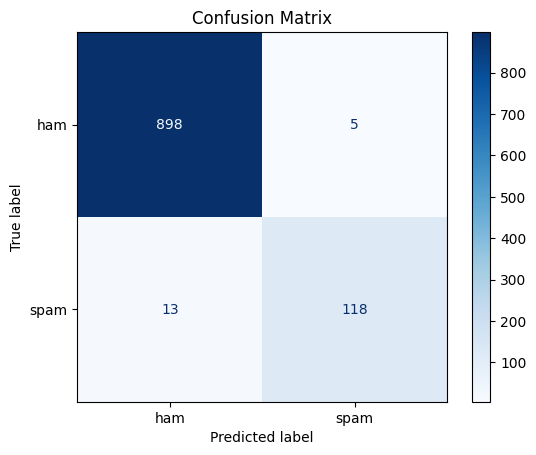

In [11]:
y_pred: np.array = grid_search.best_estimator_.predict(X_test)

accuracy: float = accuracy_score(y_test, y_pred)
precision: float = precision_score(y_test, y_pred)
recall: float = recall_score(y_test, y_pred)
f1: float = f1_score(y_test, y_pred)

print(f'Accuracy: {accuracy}')
print(f'Precision: {precision}')
print(f'Recall: {recall}')
print(f'F1 score: {f1}')

cm: np.array = confusion_matrix(y_test, y_pred)

display: ConfusionMatrixDisplay = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=df.label.unique())
display.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()